**Name - Arihant Gupta**
<br>
**Enrolment - E23CSEU0055**
<br>
**Batch - EB_02**
<br>
**Date - 09 Sep 2025**
<br>
**Lab - 11**

In [40]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
import numpy as np

 Load the dataset using Pandas and display the first 5 rows.

In [41]:
df = pd.read_excel("rd.xlsx")
print(df.head())

    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter    Class  
0  0.758651   1184.040  Kecimen  
1  0.684130   1121.786  Kecimen  
2  0.637613   1208.575  Kecimen  
3  0.699599    844.162  Kecimen  
4  0.792772   1073.251  Kecimen  


 Check for null/missing values. If present, handle them with a suitable approach.

In [42]:
print(df.isna().sum())

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


In [43]:
ndf = df.copy()
y = df["Class"]
ndf.drop("Class", inplace=True, axis=1)

 Convert the Class label into binary numeric values: Kecimen → 1, Besni → 0. 

In [44]:
lr = LabelEncoder()
y = lr.fit_transform(y)

Perform feature importance check using Chi-Square test and drop the least important 
feature(s).

In [45]:
selector = SelectKBest(chi2, k=5)
selector.fit(ndf, y)

SelectKBest(k=5, score_func=<function chi2 at 0x000002342C444180>)

In [46]:
feature_scores = pd.DataFrame({'Feature': ndf.columns, 'Score': selector.scores_})
feature_scores.sort_values(by='Score', ascending=False, inplace=True)
print(feature_scores)

           Feature         Score
4       ConvexArea  6.412753e+06
0             Area  6.097822e+06
6        Perimeter  2.563142e+04
1  MajorAxisLength  1.272952e+04
2  MinorAxisLength  2.234351e+03
3     Eccentricity  1.804260e+00
5           Extent  8.791728e-02


In [47]:
sdf = ndf[["ConvexArea", "Area", "Perimeter", "MajorAxisLength"]]
print(sdf)

     ConvexArea   Area  Perimeter  MajorAxisLength
0         90546  87524   1184.040       442.246011
1         78789  75166   1121.786       406.690687
2         93717  90856   1208.575       442.267048
3         47336  45928    844.162       286.540559
4         81463  79408   1073.251       352.190770
..          ...    ...        ...              ...
895       85839  83248   1129.072       430.077308
896       90899  87350   1214.252       440.735698
897      106264  99657   1292.828       431.706981
898       97653  93523   1258.548       476.344094
899       89197  85609   1272.862       512.081774

[900 rows x 4 columns]


Split the dataset into 80% training and 20% testing using train_test_split. 

In [48]:
x_train, x_test, y_train, y_test = train_test_split(sdf, y, test_size=0.2, random_state=42)

As asked - Decision Tree

In [49]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(x_train, y_train)

y_pred_tree = tree_clf.predict(x_test)

metrics_tree = {
    'Accuracy': accuracy_score(y_test, y_pred_tree),
    'Precision': precision_score(y_test, y_pred_tree),
    'Recall': recall_score(y_test, y_pred_tree),
    'F1-Score': f1_score(y_test, y_pred_tree)
}

print(metrics_tree)

{'Accuracy': 0.7722222222222223, 'Precision': 0.8117647058823529, 'Recall': 0.7340425531914894, 'F1-Score': 0.770949720670391}


And Random Forest

In [50]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(x_train, y_train)

y_pred_rf = rf_clf.predict(x_test)

metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}
print(metrics_rf)

{'Accuracy': 0.8222222222222222, 'Precision': 0.8522727272727273, 'Recall': 0.7978723404255319, 'F1-Score': 0.8241758241758241}


Implement AdaBoost Classifier 
 
 
a. Train an AdaBoostClassifier with default parameters.
b. Evaluate the model on the test set using: 
• Confusion Matrix 
• Accuracy 
• Precision 
• Recall

In [51]:
ada_default = AdaBoostClassifier(random_state=42)
ada_default.fit(x_train, y_train)
y_pred_default = ada_default.predict(x_test)

metrics_ada = {
    'Accuracy': accuracy_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default),
    'Recall': recall_score(y_test, y_pred_default),
    'F1-Score': f1_score(y_test, y_pred_default)
}

print(metrics_ada)

{'Accuracy': 0.85, 'Precision': 0.8602150537634409, 'Recall': 0.851063829787234, 'F1-Score': 0.8556149732620321}


Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV. 
• Example hyperparameters: 
◦ n_estimators (50, 100, 200) 
◦ learning_rate (0.01, 0.1, 1) 
◦ base_estimator (Decision Stump vs deeper tree) 
d. Report the best parameters and the performance metrics (Accuracy, Precision, 
Recall, F1).

In [52]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2)]
}

grid_search = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
             param_grid={'estimator': [DecisionTreeClassifier(max_depth=1),
                                       DecisionTreeClassifier(max_depth=2)],
                         'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [53]:
print("Best parameters:", grid_search.best_params_)
best_ada = grid_search.best_estimator_

y_pred_best = best_ada.predict(x_test)

print("Best Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-Score:", f1_score(y_test, y_pred_best))

Best parameters: {'estimator': DecisionTreeClassifier(max_depth=1), 'learning_rate': 1, 'n_estimators': 200}
Best Model Performance:
Accuracy: 0.85
Precision: 0.8681318681318682
Recall: 0.8404255319148937
F1-Score: 0.8540540540540541


Comparative Analysis 
a. Compare Decision Tree, AdaBoost, and Gradient Boosting classifiers based on: 
• Accuracy 
• Precision 
• Recall 
• F1-score 
 
 
• Training Time (optional) 
b. Draw a bar chart to show the comparison of metrics. 
c. Which model performs best for this dataset? Give a reasoning based on results. 

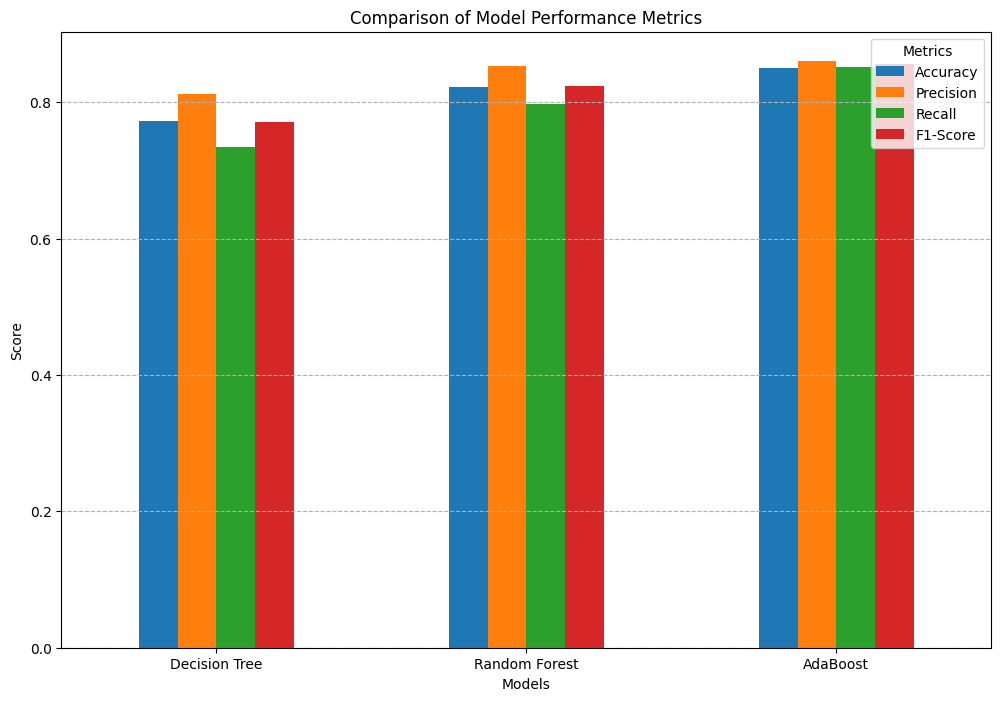

In [54]:
results_df = pd.DataFrame({
    'Decision Tree': metrics_tree,
    'Random Forest': metrics_rf,
    'AdaBoost': metrics_ada    
})

results_df_T = results_df.T

# Plot the bar chart
results_df_T.plot(kind='bar', figsize=(12, 8))
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Models')
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--')
plt.show()

In [55]:
print(metrics_ada)
print(metrics_rf)
print(metrics_tree)

{'Accuracy': 0.85, 'Precision': 0.8602150537634409, 'Recall': 0.851063829787234, 'F1-Score': 0.8556149732620321}
{'Accuracy': 0.8222222222222222, 'Precision': 0.8522727272727273, 'Recall': 0.7978723404255319, 'F1-Score': 0.8241758241758241}
{'Accuracy': 0.7722222222222223, 'Precision': 0.8117647058823529, 'Recall': 0.7340425531914894, 'F1-Score': 0.770949720670391}


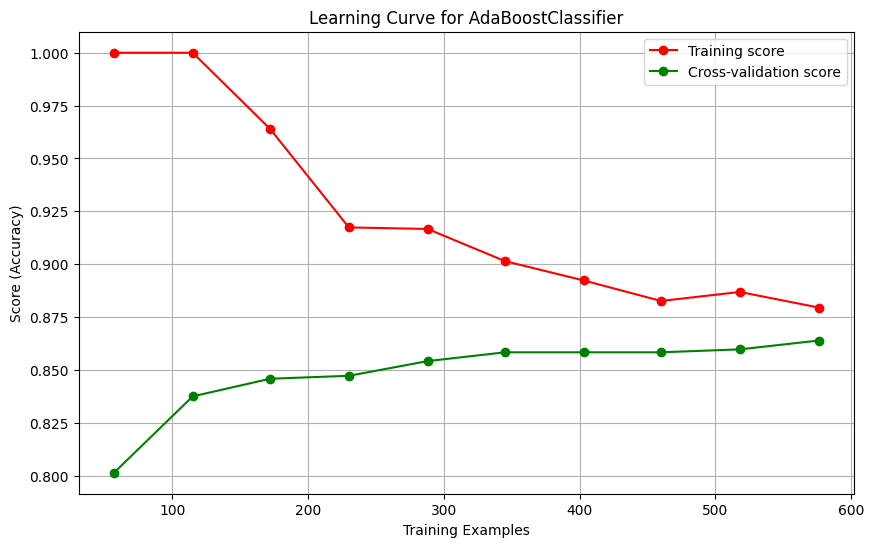

In [56]:
train_sizes, train_scores, test_scores = learning_curve(
    best_ada,
    x_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve for AdaBoostClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Score (Accuracy)")

plt.grid()

plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.legend(loc="best")
plt.show()